In [36]:
from google.colab import files
uploaded = files.upload()

Saving attention.py to attention (2).py


In [37]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.utils.vis_utils import plot_model
from keras.layers import Input,Dense,LSTM,GRU,RNN,Softmax,Dropout,AdditiveAttention,Attention
from keras import Model
from attention import AttentionLayer

In [ ]:
!wget https://storage.googleapis.com/gresearch/dakshina/dakshina_dataset_v1.0.tar
!tar -xvf '/content/dakshina_dataset_v1.0.tar'
filename = '/content/dakshina_dataset_v1.0/hi/lexicons/hi.translit.sampled.train.tsv'


**preprocessing train**

In [39]:
# Vectorize the data.
input_texts = []
target_texts = []
input_characters = set()
target_characters = set()
with open(filename, "r", encoding="utf-8") as f:
    lines = f.read().split("\n")
for line in lines[: len(lines) - 1]:
    target_text,input_text, attestation = line.split("\t")
    # We use "tab" as the "start sequence" character
    # for the targets, and "\n" as "end sequence" character.
    target_text = "\t" + target_text + "\n"
    for i in range(int(attestation)):
      input_texts.append(input_text)
      target_texts.append(target_text)
    for char in input_text:
        if char not in input_characters:
            input_characters.add(char)
    for char in target_text:
        if char not in target_characters:
            target_characters.add(char)

input_characters = sorted(list(input_characters))
target_characters = sorted(list(target_characters))
num_encoder_tokens = len(input_characters)
num_decoder_tokens = len(target_characters)
max_encoder_seq_length = max([len(txt) for txt in input_texts])
max_decoder_seq_length = max([len(txt) for txt in target_texts])

print("Number of samples:", len(input_texts))
print("Number of unique input tokens:", num_encoder_tokens)
print("Number of unique output tokens:", num_decoder_tokens)
print("Max sequence length for inputs:", max_encoder_seq_length)
print("Max sequence length for outputs:", max_decoder_seq_length)

Number of samples: 84942
Number of unique input tokens: 26
Number of unique output tokens: 65
Max sequence length for inputs: 20
Max sequence length for outputs: 21


In [40]:
input_token_index = dict([(char, i) for i, char in enumerate(input_characters)])
target_token_index = dict([(char, i) for i, char in enumerate(target_characters)])

reverse_input_char_index = dict((i, char) for char, i in input_token_index.items())
reverse_target_char_index = dict((i, char) for char, i in target_token_index.items())

#max_seq_length = max(max_encoder_seq_length,max_decoder_seq_length)

encoder_input_data = np.zeros(
    (len(input_texts), max_encoder_seq_length, num_encoder_tokens), dtype="float32"
)
decoder_input_data = np.zeros(
    (len(input_texts), max_decoder_seq_length, num_decoder_tokens), dtype="float32"
)
decoder_target_data = np.zeros(
    (len(input_texts), max_decoder_seq_length, num_decoder_tokens), dtype="float32"
)

for i, (input_text, target_text) in enumerate(zip(input_texts, target_texts)):
    for t, char in enumerate(input_text):
        encoder_input_data[i, t, input_token_index[char]] = 1.0
    for t, char in enumerate(target_text):
        # decoder_target_data is ahead of decoder_input_data by one timestep
        decoder_input_data[i, t, target_token_index[char]] = 1.0
        if t > 0:
            # decoder_target_data will be ahead by one timestep
            # and will not include the start character.
            decoder_target_data[i, t - 1, target_token_index[char]] = 1.0

**preprocess data**

In [41]:
def preprocess_Data(file_path,max_encoder_seq_length,max_decoder_seq_length,num_encoder_tokens,num_decoder_tokens,input_token_index,target_token_index):

  input_texts = []
  target_texts = []

  with open(file_path, "r", encoding="utf-8") as f:
      lines = f.read().split("\n")
  for line in lines[: len(lines) - 1]:
      target_text,input_text, attestation = line.split("\t")
      # We use "tab" as the "start sequence" character
      # for the targets, and "\n" as "end sequence" character.
      target_text = "\t" + target_text + "\n"
      for i in range(int(attestation)):
        input_texts.append(input_text)
        target_texts.append(target_text)


  encoder_input_data = np.zeros(
      (len(input_texts), max_encoder_seq_length, num_encoder_tokens), dtype="float32"
  )
  decoder_input_data = np.zeros(
      (len(input_texts), max_decoder_seq_length, num_decoder_tokens), dtype="float32"
  )
  decoder_target_data = np.zeros(
      (len(input_texts), max_decoder_seq_length, num_decoder_tokens), dtype="float32"
  )

  for i, (input_text, target_text) in enumerate(zip(input_texts, target_texts)):
      for t, char in enumerate(input_text):
          encoder_input_data[i, t, input_token_index[char]] = 1.0
      for t, char in enumerate(target_text):
          # decoder_target_data is ahead of decoder_input_data by one timestep
          decoder_input_data[i, t, target_token_index[char]] = 1.0
          if t > 0:
              # decoder_target_data will be ahead by one timestep
              # and will not include the start character.
              decoder_target_data[i, t - 1, target_token_index[char]] = 1.0

  return (input_texts ,target_texts ,encoder_input_data,decoder_input_data,decoder_target_data)
  

In [42]:
file_path = '/content/dakshina_dataset_v1.0/hi/lexicons/hi.translit.sampled.dev.tsv'
en_ip_val_text ,de_ip_val_text , en_ip_val_data , de_ip_val_data , de_op_val_data = preprocess_Data(file_path,max_encoder_seq_length,max_decoder_seq_length,
                                                                   num_encoder_tokens,num_decoder_tokens,input_token_index,
                                                                   target_token_index)


**create model with attention**

In [43]:
latent_dims = [64,128,256]
encoder_inputs = Input(shape=(None,num_encoder_tokens))

outputs = encoder_inputs
encoder_states = []
encoder_OPs = []
input_layers = []
for j in range(len(latent_dims))[::-1]:
  input_layers.append(
      keras.layers.LSTM(latent_dims[j],return_state=True, return_sequences=True))
  outputs, h, c = input_layers[-1](outputs)
  encoder_states += [h, c]
  encoder_OPs+=[outputs]
  
encoder_outputs=outputs

decoder_inputs = keras.layers.Input(shape=(None,num_decoder_tokens))

outputs = decoder_inputs
output_layers = []
for j in range(len(latent_dims)):
    output_layers.append(
        keras.layers.LSTM(latent_dims[len(latent_dims) - j - 1], return_sequences=True, return_state=True)
    )
    outputs, dh, dc = output_layers[-1](outputs, initial_state=encoder_states[2*j:2*(j+1)])
decoder_outputs=outputs
 
attn_layer = AttentionLayer(name='attention_layer')
attn_out, attn_states = attn_layer([encoder_outputs,decoder_outputs])

decoder_concat_input = keras.layers.Concatenate(axis=-1, name='concat_layer')([decoder_outputs, attn_out])
dense = keras.layers.Dense(num_decoder_tokens, activation='softmax', name='softmax_layer')

dense_time = keras.layers.TimeDistributed(dense, name='time_distributed_layer')
decoder_pred = dense_time(decoder_concat_input)


model = keras.Model([encoder_inputs, decoder_inputs], decoder_pred)
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [7]:


'''latent_dim=256
encoder_inputs = Input(shape=(max_encoder_seq_length, num_encoder_tokens), name='encoder_inputs')
decoder_inputs = Input(shape=(max_decoder_seq_length, num_decoder_tokens), name='decoder_inputs')


encoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True, name='encoder_lstm')
encoder_out, encoder_state_h, encoder_state_c = encoder_lstm(encoder_inputs)
encoder_state = [encoder_state_h,encoder_state_c]

# Set up the decoder LSTM, using `encoder_states` as initial state.
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True, name='decoder_lstm')
decoder_out, decoder_state_h, decoder_state_c = decoder_lstm(decoder_inputs, initial_state=encoder_state)

# Attention layer
attn_layer = AttentionLayer(name='attention_layer')
attn_out, attn_states = attn_layer([encoder_out, decoder_out])

# Concat attention output and decoder lstm output
decoder_concat_input = keras.layers.Concatenate(axis=-1, name='concat_layer')([decoder_out, attn_out])

# Dense layer
dense = Dense(num_decoder_tokens, activation='softmax', name='softmax_layer')
dense_time = keras.layers.TimeDistributed(dense, name='time_distributed_layer')
decoder_pred = dense_time(decoder_concat_input)

# Full model
model = Model(inputs=[encoder_inputs, decoder_inputs], outputs=decoder_pred)
model.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy'])'''

In [44]:
model.fit([encoder_input_data, decoder_input_data],
        decoder_target_data,
        batch_size=32,
        epochs=20,
        validation_data = ([en_ip_val_data , de_ip_val_data],de_op_val_data))

Epoch 1/20
2655/2655 [==============================] - 163s 58ms/step - loss: 0.7564 - accuracy: 0.1371 - val_loss: 0.2006 - val_accuracy: 0.2622
Epoch 2/20
2655/2655 [==============================] - 154s 58ms/step - loss: 0.1818 - accuracy: 0.2802 - val_loss: 0.1523 - val_accuracy: 0.2752
Epoch 3/20
2655/2655 [==============================] - 154s 58ms/step - loss: 0.1326 - accuracy: 0.2945 - val_loss: 0.1355 - val_accuracy: 0.2811
Epoch 4/20
2655/2655 [==============================] - 155s 58ms/step - loss: 0.1100 - accuracy: 0.3020 - val_loss: 0.1256 - val_accuracy: 0.2839
Epoch 5/20
2655/2655 [==============================] - 154s 58ms/step - loss: 0.0926 - accuracy: 0.3093 - val_loss: 0.1227 - val_accuracy: 0.2852
Epoch 6/20
2655/2655 [==============================] - 155s 58ms/step - loss: 0.0786 - accuracy: 0.3122 - val_loss: 0.1233 - val_accuracy: 0.2859
Epoch 7/20
2655/2655 [==============================] - 154s 58ms/step - loss: 0.0692 - accuracy: 0.3164 - val_loss: 0

**inference setup**

In [ ]:
# Define sampling models (modified for n-layer deep network)
batch_size = 1

encoder_inf_inputs = Input(batch_shape = (batch_size,max_encoder_seq_length,num_encoder_tokens))
enc_op = encoder_inf_inputs

enc_inf_OPs=[]
enc_inf_states = []
#pass this input to each enc layer from the model and get the final op...
for j in range(len(latent_dims)):
  enc_op , enc_inf_state_h , enc_inf_state_c = input_layers[j](enc_op)
  enc_inf_OPs+=[enc_op]
  enc_inf_states+=[enc_inf_state_h , enc_inf_state_c]

#producing 1 finalop from encoder and layers as [h256,c256,h128,c128,h64,c64]... 
encoder_model = Model(encoder_inf_inputs, [enc_op,enc_inf_states])


decoder_inf_inputs = Input(batch_shape = (batch_size ,1 , num_decoder_tokens))

#encoder ops for all time steps (for the last enc layer only..)
encoder_inf_states = Input(batch_shape = (batch_size,max_encoder_seq_length,latent_dims[0]))

#pass this input to every layer of decoder and get the output...
dec_op = decoder_inf_inputs
dec_init_states=[]
dec_inf_states = []
for j in range(len(latent_dims)):

  idx = len(latent_dims)-j-1
  #attach the ip state of corresponding encoder..
  dec_init_state = [Input(batch_shape=(batch_size,latent_dims[idx])) for _ in range(2)]

  dec_op ,dec_inf_state_h , dec_inf_state_c = output_layers[j](dec_op , initial_state = dec_init_state)

  dec_init_states+=[dec_init_state]
  dec_inf_states+=[dec_inf_state_h , dec_inf_state_c]

#apply attention layer to the last decoder layer op and last encoderlayer state...
attn_inf_out, attn_inf_states = attn_layer([encoder_inf_states, dec_op])

#concatenate att_out and dec_out..
decoder_inf_concat = keras.layers.Concatenate(axis = -1,name='concat')([dec_op , attn_inf_out])

decoder_inf_pred = model.get_layer('time_distributed_layer')(decoder_inf_concat)

decoder_model = Model(inputs = [encoder_inf_states,dec_init_states,decoder_inf_inputs],
                      outputs = [decoder_inf_pred,attn_inf_states,dec_inf_states])

In [101]:
''' """ Inference model """
batch_size = 1

""" Encoder (Inference) model """
encoder_inf_inputs = Input(batch_shape=(batch_size, max_encoder_seq_length, num_encoder_tokens), name='encoder_inf_inputs')
encoder_inf_out, encoder_inf_state_h, encoder_inf_state_c = encoder_lstm(encoder_inf_inputs)
encoder_inf_state = [encoder_inf_state_h,encoder_inf_state_c]

encoder_model = Model(inputs=encoder_inf_inputs, outputs=[encoder_inf_out, encoder_inf_state])

""" Decoder (Inference) model """
decoder_inf_inputs = Input(batch_shape=(batch_size, 1, num_decoder_tokens), name='decoder_word_inputs')

#encoder states for all time steps..
encoder_inf_states = Input(batch_shape=(batch_size, max_encoder_seq_length, latent_dim), name='encoder_inf_states')

decoder_init_state = [Input(batch_shape=(batch_size, latent_dim)) for i in range(2)]

decoder_inf_out, decoder_inf_state_h, decoder_inf_state_c = decoder_lstm(decoder_inf_inputs,initial_state=decoder_init_state)
decoder_inf_state = [decoder_inf_state_h,decoder_inf_state_c]

attn_inf_out, attn_inf_states = attn_layer([encoder_inf_states, decoder_inf_out])
decoder_inf_concat = keras.layers.Concatenate(axis=-1, name='concat')([decoder_inf_out, attn_inf_out])

decoder_inf_pred = keras.layers.TimeDistributed(dense)(decoder_inf_concat)
decoder_model = Model(inputs=[encoder_inf_states, decoder_init_state, decoder_inf_inputs],
                          outputs=[decoder_inf_pred, attn_inf_states, decoder_inf_state])'''

In [28]:
def decode_sequence(input_seq, encoder_model, decoder_model):
    # Encode the input as state vectors.
    enc_op , states_value = encoder_model.predict(input_seq)
    # Generate empty target sequence of length 1.
    target_seq = np.zeros((1, 1, num_decoder_tokens))
    # Populate the first character of target sequence with the start character.
    target_seq[0, 0, target_token_index['\t']] = 1.

    # Sampling loop for a batch of sequences
    # (to simplify, here we assume a batch of size 1).
    stop_condition = False
    decoded_sentence = []  #Creating a list then using "".join() is usually much faster for string creation
    att_mtx = []
    char_by_char = []
    while not stop_condition:
      to_split = decoder_model.predict([enc_op,states_value,target_seq])

      output_tokens, att_weights, states_value = to_split[0], to_split[1], to_split[2]

      # Sample a token
      sampled_token_index = np.argmax(output_tokens[0, 0])
      sampled_char = reverse_target_char_index[sampled_token_index]
      char_by_char.append(sampled_char)
      decoded_sentence.append(sampled_char)

      #collect the attention weights
      att_mtx.append(att_weights)
      # Exit condition: either hit max length
      # or find stop character.
      if sampled_char == '\n' or len(decoded_sentence) > max_decoder_seq_length:
          stop_condition = True

      # Update the target sequence (of length 1).
      target_seq = np.zeros((1, 1, num_decoder_tokens))
      target_seq[0, 0, sampled_token_index] = 1.
      
    
    return ("".join(decoded_sentence),char_by_char,att_mtx)

**preprocess the test data**

In [31]:
# Vectorize the test data...
file_path = '/content/dakshina_dataset_v1.0/hi/lexicons/hi.translit.sampled.test.tsv'
en_ip_ts_texts, de_ip_ts_texts ,en_ip_ts_data , de_ip_ts_data , de_op_ts_data = preprocess_Data(file_path,max_encoder_seq_length,max_decoder_seq_length,
                                                                   num_encoder_tokens,num_decoder_tokens,input_token_index,
                                                                   target_token_index)

**running inference for test data**

In [45]:
for seq_index in range(50):
    # Take one sequence (part of the test set)
    # for trying out decoding.
    st=seq_index+1000
    en=seq_index+1001
    input_seq = en_ip_ts_data[st:en]
    decoded_sentence,char_by_char,att_mtx = decode_sequence(input_seq,encoder_model,decoder_model)
    print('------')
    print('Input word:', en_ip_ts_texts[st])
    #print('Target sentence:', target_test_texts[st])
    print('Predicted chars:', char_by_char)
    print('Decoded word:', decoded_sentence)


------
Input word: asian
Predicted chars: ['अ', 'स', 'ि', 'य', 'ा', 'न', '\n']
Decoded word: असियान

------
Input word: sfc
Predicted chars: ['स', 'ी', 'स', 'ी', 'स', 'ी', '\n']
Decoded word: सीसीसी

------
Input word: sfc
Predicted chars: ['स', 'ी', 'स', 'ी', 'स', 'ी', '\n']
Decoded word: सीसीसी

------
Input word: sfc
Predicted chars: ['स', 'ी', 'स', 'ी', 'स', 'ी', '\n']
Decoded word: सीसीसी

------
Input word: sk
Predicted chars: ['स', 'ी', 'क', 'े', '\n']
Decoded word: सीके

------
Input word: sk
Predicted chars: ['स', 'ी', 'क', 'े', '\n']
Decoded word: सीके

------
Input word: sk
Predicted chars: ['स', 'ी', 'क', 'े', '\n']
Decoded word: सीके

------
Input word: spf
Predicted chars: ['स', 'ी', 'ए', 'प', 'फ', 'ी', '\n']
Decoded word: सीएपफी

------
Input word: spf
Predicted chars: ['स', 'ी', 'ए', 'प', 'फ', 'ी', '\n']
Decoded word: सीएपफी

------
Input word: spf
Predicted chars: ['स', 'ी', 'ए', 'प', 'फ', 'ी', '\n']
Decoded word: सीएपफी

------
Input word: association
Predicted chars:

**Plotting the heatmap for 1 test point**

In [46]:
input_seq = encoder_input_test_data[20:21]
decoded_sentence,char_by_char,att_mtx = decode_sequence(input_seq,encoder_model,decoder_model)
source = input_test_texts[20].split()
char_by_char[-1]='<end>'
mtx = []
for i in range(len(char_by_char)):
  mtx.append(att_mtx[i][0][0])


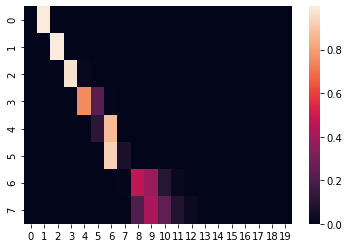

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(mtx)


In [110]:
char_by_char[-1] = '<end>'
char_by_char

['अ', 'ं', 'ग', '्', 'र', 'े', 'ज', 'ी', '<end>']